# Baselines para previsão de demanda de manutenções

Este notebook estabelece um piso de comparação para o futuro modelo de Machine Learning. Ele compara um modelo ingênuo e médias móveis de 7 e 30 dias, sempre usando apenas dados que já existiam no momento da previsão.

## Dados esperados

Disponibilize o arquivo `data/manutencoes_diarias.csv` com as colunas `data` (data do dia) e `manutencoes` (quantidade de manutenções). Deve existir, no máximo, uma linha por dia; dias sem atendimento podem ser incluídos com valor zero.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_PATH = Path('../data/manutencoes_diarias.csv')
HORIZONTE = 14  # quantidade de dias futuros a projetar
JANELAS = (7, 30)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def carregar_serie_diaria(caminho: Path) -> pd.Series:
    """Carrega e valida a série diária de manutenções."""
    if not caminho.exists():
        raise FileNotFoundError(
            f'Arquivo não encontrado: {caminho.resolve()}. ' 
            'Crie data/manutencoes_diarias.csv com as colunas data e manutencoes.'
        )

    dados = pd.read_csv(caminho)
    obrigatorias = {'data', 'manutencoes'}
    faltantes = obrigatorias - set(dados.columns)
    if faltantes:
        raise ValueError(f'Colunas obrigatórias ausentes: {sorted(faltantes)}')

    dados['data'] = pd.to_datetime(dados['data'], errors='raise')
    dados['manutencoes'] = pd.to_numeric(dados['manutencoes'], errors='raise')
    if (dados['manutencoes'] < 0).any():
        raise ValueError('A quantidade de manutenções não pode ser negativa.')
    if dados['data'].duplicated().any():
        raise ValueError('Há mais de um registro para a mesma data. Agregue os dados antes de usar o notebook.')

    serie = dados.set_index('data')['manutencoes'].sort_index().asfreq('D', fill_value=0.0)
    serie.name = 'real'
    return serie.astype(float)


def previsao_naive(serie: pd.Series, horizonte: int = 1) -> pd.Series:
    """Prevê cada próximo dia como igual ao último valor conhecido."""
    if serie.empty or horizonte < 1:
        raise ValueError('A série não pode estar vazia e o horizonte deve ser maior que zero.')
    indice = pd.date_range(serie.index[-1] + pd.Timedelta(days=1), periods=horizonte, freq='D')
    return pd.Series(float(serie.iloc[-1]), index=indice, name='naive')


def previsao_media_movel(serie: pd.Series, janela: int, horizonte: int = 1) -> pd.Series:
    """Projeta os próximos dias pela média dos últimos `janela` dias observados."""
    if janela < 1 or len(serie) < janela or horizonte < 1:
        raise ValueError('Janela e horizonte inválidos ou histórico insuficiente.')
    indice = pd.date_range(serie.index[-1] + pd.Timedelta(days=1), periods=horizonte, freq='D')
    media = float(serie.iloc[-janela:].mean())
    return pd.Series(media, index=indice, name=f'mm_{janela}')


def previsoes_historicas(serie: pd.Series, janela: int) -> pd.DataFrame:
    """Gera previsões de um passo à frente, sem usar a demanda do próprio dia."""
    resultado = pd.DataFrame({'real': serie})
    resultado['naive'] = serie.shift(1)
    resultado[f'mm_{janela}'] = serie.shift(1).rolling(window=janela, min_periods=janela).mean()
    return resultado


In [3]:
serie = carregar_serie_diaria(CSV_PATH)
if len(serie) < max(JANELAS) + 1:
    raise ValueError(f'São necessários ao menos {max(JANELAS) + 1} dias de histórico.')

serie.tail()

data
2026-04-06    18.0
2026-04-07    17.0
2026-04-08    21.0
2026-04-09    43.0
2026-04-10    42.0
Freq: D, Name: real, dtype: float64

In [4]:
# Backtest: cada previsão usa exclusivamente dias anteriores.
avaliacao = previsoes_historicas(serie, janela=7)
for janela in JANELAS:
    avaliacao[f'mm_{janela}'] = serie.shift(1).rolling(janela, min_periods=janela).mean()

metricas = []
for modelo in ['naive', *[f'mm_{janela}' for janela in JANELAS]]:
    comparavel = avaliacao[['real', modelo]].dropna()
    erro = comparavel['real'] - comparavel[modelo]
    metricas.append({
        'modelo': modelo,
        'observações avaliadas': len(comparavel),
        'MAE': erro.abs().mean(),
        'RMSE': np.sqrt((erro ** 2).mean()),
    })

metricas = pd.DataFrame(metricas).sort_values('MAE').reset_index(drop=True)
metricas.round(2)

,modelo,observações avaliadas,MAE,RMSE
0,mm_30,70,10.49,11.96
1,mm_7,93,10.51,12.42
2,naive,99,13.29,16.19


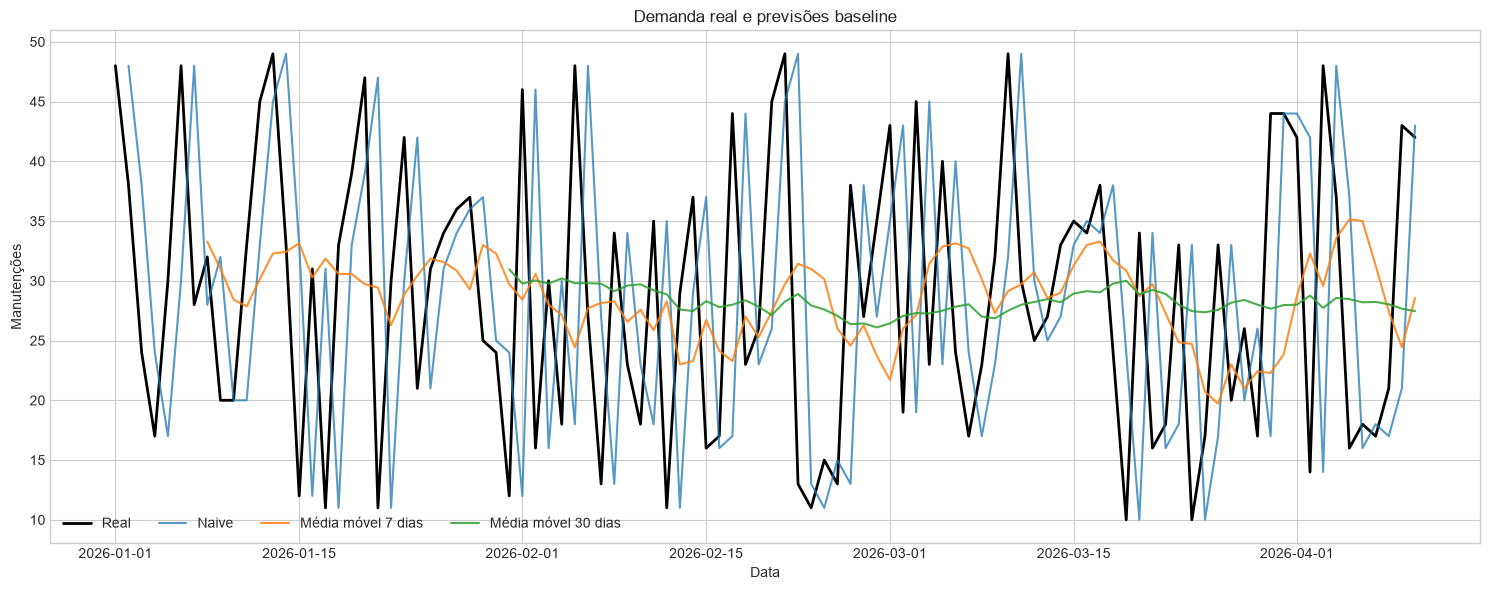

In [5]:
# Histórico real sobreposto às previsões históricas (um dia à frente).
inicio_plot = max(serie.index.min(), serie.index.max() - pd.Timedelta(days=120))
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(serie.loc[inicio_plot:], label='Real', color='black', linewidth=2)
ax.plot(avaliacao.loc[inicio_plot:, 'naive'], label='Naive', alpha=.75)
ax.plot(avaliacao.loc[inicio_plot:, 'mm_7'], label='Média móvel 7 dias', alpha=.85)
ax.plot(avaliacao.loc[inicio_plot:, 'mm_30'], label='Média móvel 30 dias', alpha=.85)
ax.set(title='Demanda real e previsões baseline', xlabel='Data', ylabel='Manutenções')
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

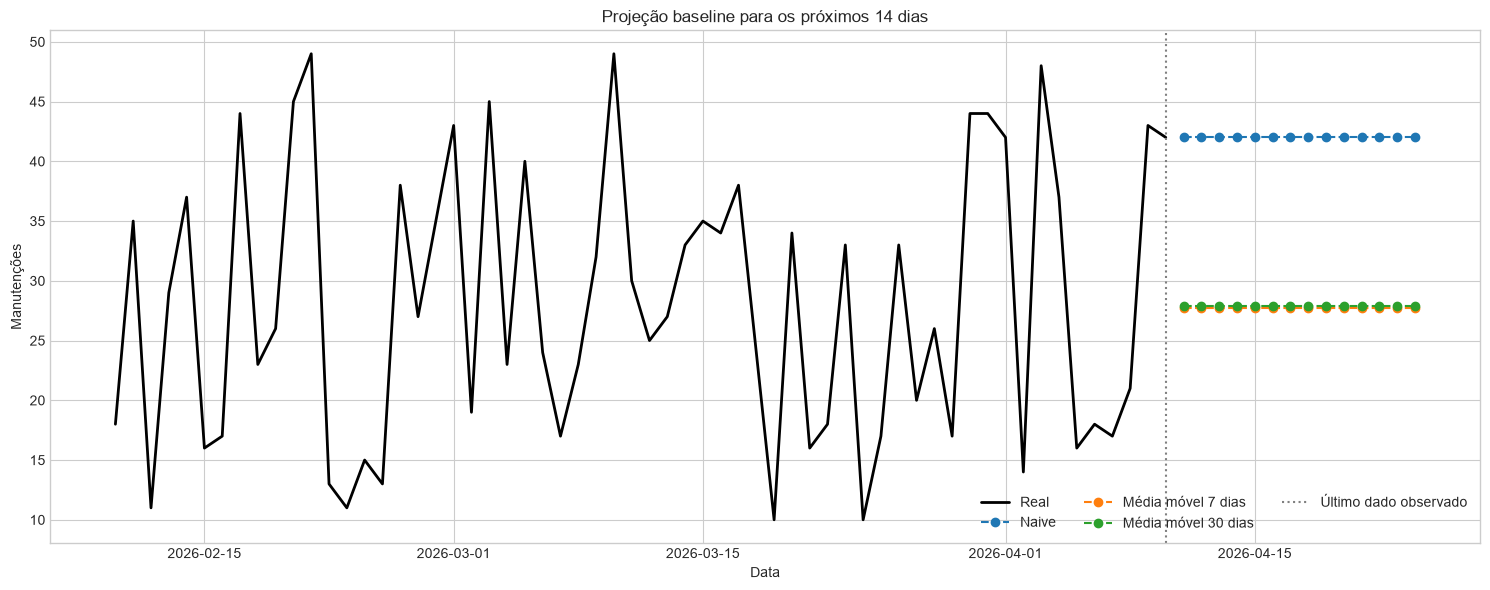

,naive,mm_7,mm_30
2026-04-11,42.0,27.71,27.87
2026-04-12,42.0,27.71,27.87
2026-04-13,42.0,27.71,27.87
2026-04-14,42.0,27.71,27.87
2026-04-15,42.0,27.71,27.87
2026-04-16,42.0,27.71,27.87
2026-04-17,42.0,27.71,27.87
2026-04-18,42.0,27.71,27.87
2026-04-19,42.0,27.71,27.87
2026-04-20,42.0,27.71,27.87


In [6]:
# Projeção para os próximos dias. As médias são constantes porque não há novas observações futuras.
futuro = pd.concat([
    previsao_naive(serie, HORIZONTE),
    previsao_media_movel(serie, 7, HORIZONTE),
    previsao_media_movel(serie, 30, HORIZONTE),
], axis=1)

fig, ax = plt.subplots(figsize=(15, 6))
historico_recente = serie.tail(60)
ax.plot(historico_recente, label='Real', color='black', linewidth=2)
for coluna, rotulo in [('naive', 'Naive'), ('mm_7', 'Média móvel 7 dias'), ('mm_30', 'Média móvel 30 dias')]:
    ax.plot(futuro.index, futuro[coluna], marker='o', linestyle='--', label=rotulo)
ax.axvline(serie.index[-1], color='gray', linestyle=':', label='Último dado observado')
ax.set(title=f'Projeção baseline para os próximos {HORIZONTE} dias', xlabel='Data', ylabel='Manutenções')
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

futuro.round(2)